In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
from PIL import Image

# **Power method**

(a) Write a program to implement the power method for computing the first left singular vector of a matrix. Apply your program to the matrix
$$
\mathbf{A} = \begin{pmatrix}
1 & 2 & 3 & \cdots & 9 & 10\\
2 & 3 & 4 & \cdots & 10 & 0\\
\vdots & \vdots & \vdots &  & \vdots & \vdots\\
9 & 10 & 0 & \cdots & 0 & 0 \\
10 & 0 & 0 & \cdots & 0 & 0
\end{pmatrix}
$$

In [5]:
#the matrix A
A = np.array([[1,2,3,4,5,6,7,8,9,10],
              [2,3,4,5,6,7,8,9,10,0],
              [3,4,5,6,7,8,9,10,0,0],
              [4,5,6,7,8,9,10,0,0,0],
              [5,6,7,8,9,10,0,0,0,0],
              [6,7,8,9,10,0,0,0,0,0],
              [7,8,9,10,0,0,0,0,0,0],
              [8,9,10,0,0,0,0,0,0,0],
              [9,10,0,0,0,0,0,0,0,0],
              [10,0,0,0,0,0,0,0,0,0],])

def powermethod_part_a(M, tol, max_iter):
    #random vector 
    x = np.random.normal(0.0, 1.0, size=(M.shape[0], 1))
    
    for k in range(max_iter):
        x_new = M @ (M.T @ x)

        #new trial value for u1
        x_new /= np.linalg.norm(x_new)
        
        #check how different new value is from previous one
        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new
    return x

u1 = powermethod_part_a(A, 1e-12, 100)
print(u1)

[[-0.3197506 ]
 [-0.36962502]
 [-0.39811309]
 [-0.4039189 ]
 [-0.38728043]
 [-0.3499587 ]
 [-0.29512626]
 [-0.22716239]
 [-0.15136864]
 [-0.07362363]]


(b) Implement a modification of the power method that computes the first four left singular vectors of a matrix, as follows. Randomly select four vectors and find an orthonormal basis for the space spanned by the four vectors. Then multiply each of the basis vectors by $\mathbf{A\,A}^\top$ and find a new othonormal basis for the space spanned by the resulting four vectors. Apply your code to compute the first four singular vectors of the matrix from part (a). 

In [7]:
def powermethod_partb(M, numvecs, tol, max_iter):
    #matrix x = [x_1|x_2|...|x_numvecs]
    x = np.random.normal(0.0, 1.0, size=(M.shape[0], numvecs))

    for k in range(max_iter):
        E = np.zeros((M.shape[0], numvecs))

        #Gram-schmidt, creates E = [e_1|e_2|...|e_numvecs] where the e_i are an othonormal 
        #basis for the space spanned by the column vectors of x
        for j in range(numvecs):
            e = x[:, j].copy()  # take the j-th column
        
            # Subtract the projections onto previous column vectors
            for i in range(j):
                e -= np.dot(E[:, i], e) * E[:, i]
        
            # Normalize
            norm = np.linalg.norm(e)
            E[:, j] = e / norm

        #new trial value for u_1,u_2,...,u_numvecs
        x_new = M @ (M.T @ E)
        x_new = x_new / np.linalg.norm(x_new, axis=0, keepdims=True)

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new
    return x

U = powermethod_partb(A, 4, 1e-12, 100)
print(U)

[[ 0.3197506  -0.45784552 -0.42415456  0.39363387]
 [ 0.36962502 -0.3936509  -0.24288284  0.02849182]
 [ 0.39811309 -0.25497036  0.07043602 -0.36152104]
 [ 0.4039189  -0.06980555  0.33936334 -0.38322644]
 [ 0.38728043  0.12450888  0.41233765 -0.014406  ]
 [ 0.3499587   0.2887672   0.24775341  0.37382129]
 [ 0.29512626  0.38972804 -0.06268814  0.39083196]
 [ 0.22716239  0.40675711 -0.34546459  0.01997829]
 [ 0.15136864  0.33594883 -0.44265159 -0.36463802]
 [ 0.07362363  0.19090282 -0.30058613 -0.3749948 ]]


# **SVD**
Read in a grayscale image of resolution at least 256 by 256. Perform a singular value decomposition of the matrix. Reconstruct the image using only the 1, 4, 16, and 32 singular values/singular vectors. Do the same for a "white noise" image and take note of the percentage of the Frobenius norm captured in each case.

In [8]:
# Load the image
img = Image.open("grayscale_img.png").convert("L")  # 'L' mode = grayscale

# Resize to 256x256
img = img.resize((256, 256))

# Convert to numpy array
img_array = np.array(img)

#Compute the SVD of M with "rank" singular values/vectors
def svd(M, rank, tol, max_iter):
    # matrix x = [x_1|x_2|...|x_rank] where the columns are each a random vector
    x = np.random.normal(0.0, 1.0, size=(M.shape[0], rank))

    for k in range(max_iter):
        E = np.zeros((M.shape[0], rank))

        #Gram-schmidt, creates E = [e_1|e_2|...|e_numvecs] where the e_i are an othonormal 
        #basis for the space spanned by the column vectors of x
        for j in range(rank):
            e = x[:, j].copy()  # take the j-th column
        
            # Subtract the projections onto previous column vectors
            for i in range(j):
                e -= np.dot(E[:, i], e) * E[:, i]
        
            # Normalize
            norm = np.linalg.norm(e)
            E[:, j] = e / norm

        #new trial value for u_1,u_2,...,u_numvecs
        x_new = M @ (M.T @ E)
        x_new = x_new / np.linalg.norm(x_new, axis=0, keepdims=True)

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    #left singular vectors in matrix form U^i_(a)
    U = np.zeros((M.shape[0], M.shape[0]))
    U[:, :rank] = x
        
    #right singular vectors in matrix form times singular values, V^i_(a) \Sig^a_b
    VSig = M.T @ U

    #Singular values times transpose of V, \Sig^a_b V^(a)_i
    SigVT = VSig.T

    #SVD = U^i_(a) \Sigma^a_b V^(b)_j
    SVD = U @ SigVT

    #Frobenius norm captured
    FBnorm = np.linalg.norm(SVD)
    FBreal = np.linalg.norm(M)
    frac = FBnorm/FBreal
    return SVD, frac

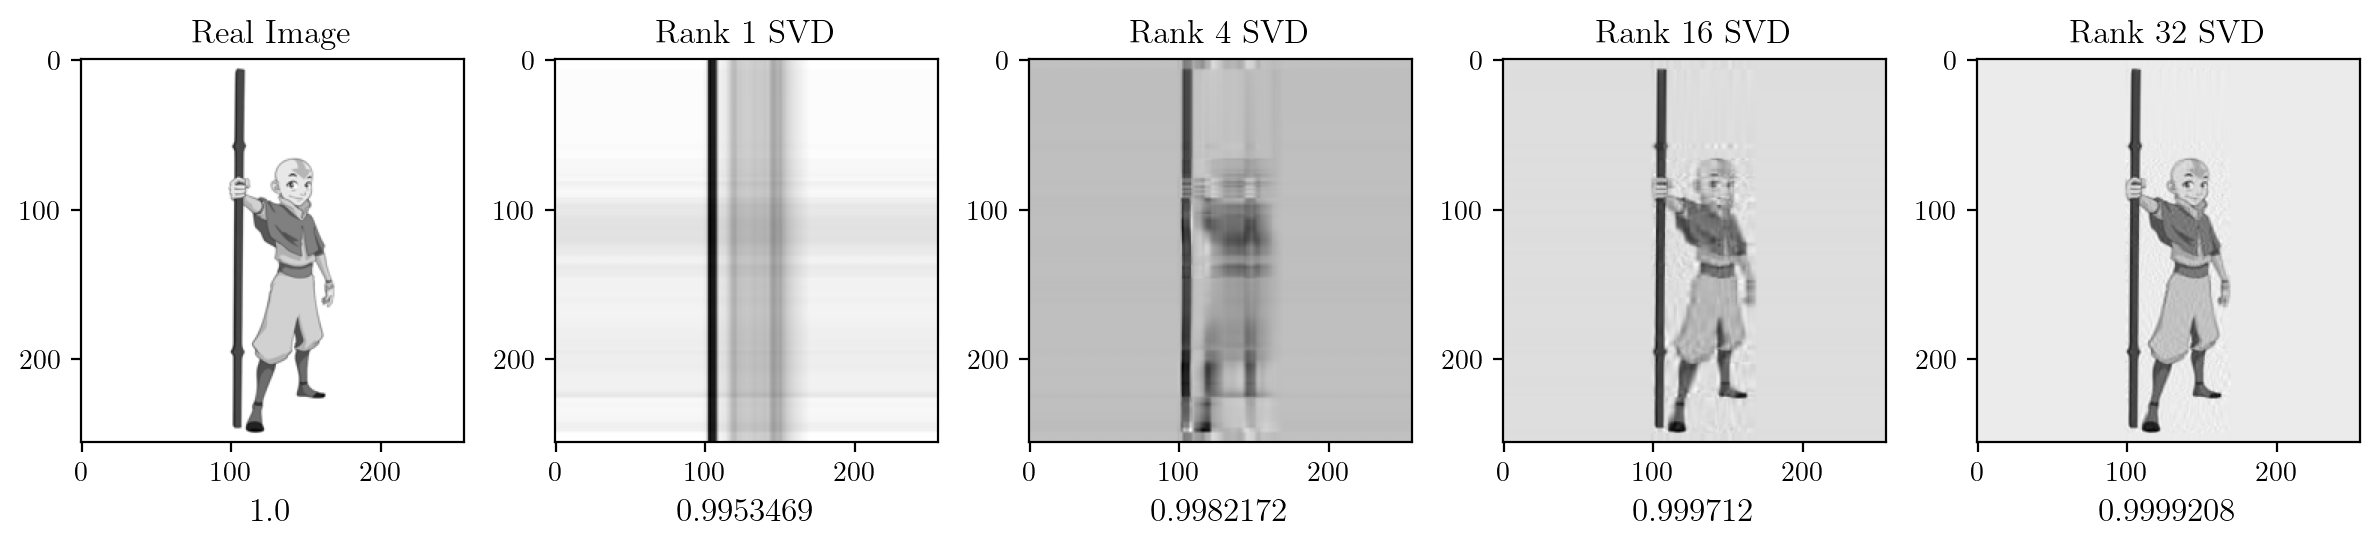

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3), dpi=200)

img1 = img_array
img2, frac2 = svd(img_array, 1, 1e-12, 100)
img3, frac3 = svd(img_array, 4, 1e-12, 100)
img4, frac4 = svd(img_array, 16, 1e-12, 100)
img5, frac5 = svd(img_array, 32, 1e-12, 100)


images = [img1, img2, img3, img4, img5]  # replace with your 4 matrices
labels = ["Real Image", "Rank 1 SVD", "Rank 4 SVD", "Rank 16 SVD", "Rank 32 SVD"]
labels = ["Real Image", "Rank 1 SVD", "Rank 4 SVD", "Rank 16 SVD", "Rank 32 SVD"]
fracs = [1.0000000, round(frac2, 7), round(frac3, 7), round(frac4, 7), round(frac5, 7)]

for ax, img, label, frac in zip(axes, images, labels, fracs):
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(frac, fontsize=12)
    ax.set_yticks([0, 100, 200])

plt.tight_layout()
plt.show()

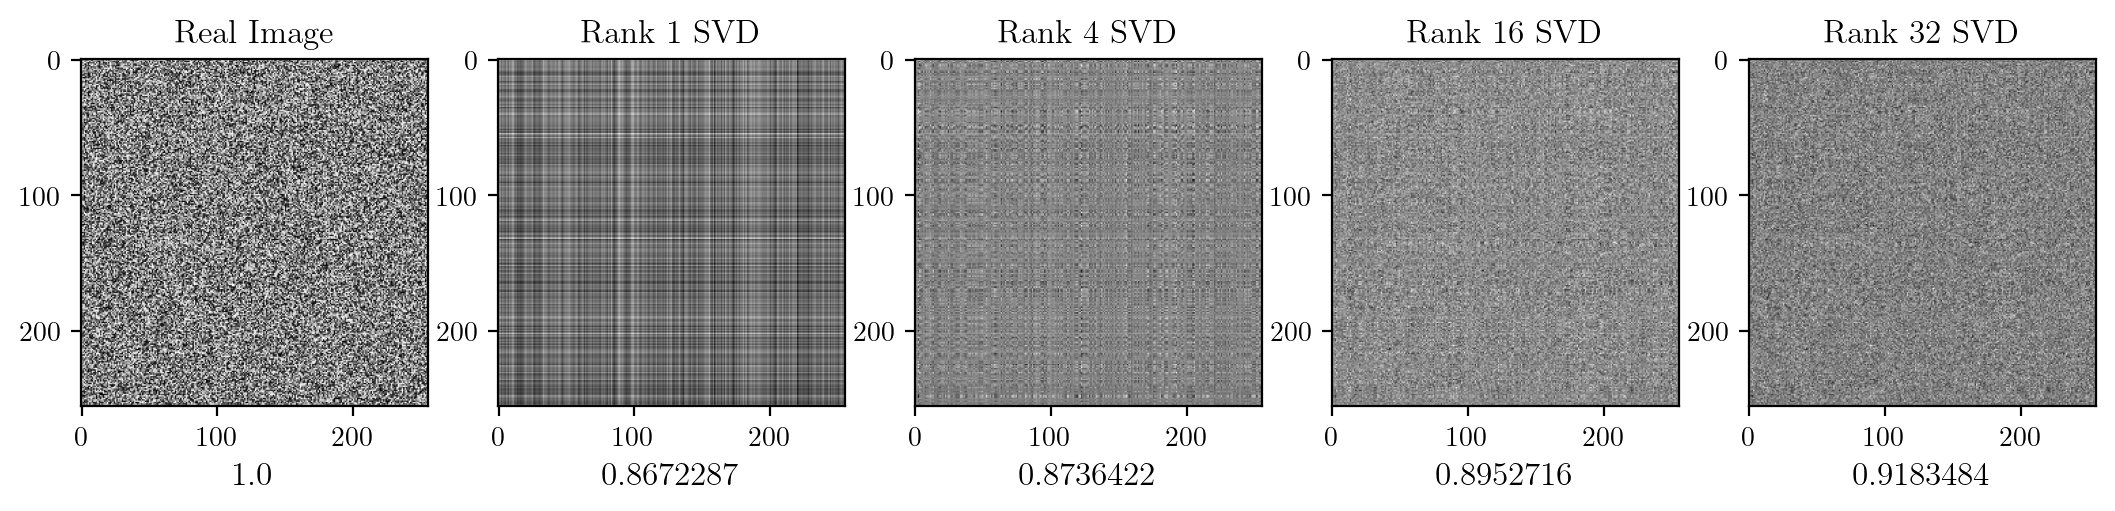

In [10]:
img_partc = np.random.uniform(0.0, 1.0, size=(256, 256))

fig, axes = plt.subplots(1, 5, figsize=(13, 3), dpi=200)

img1 = img_partc
img2, frac2 = svd(img_partc, 1, 1e-12, 100)
img3, frac3 = svd(img_partc, 4, 1e-12, 100)
img4, frac4 = svd(img_partc, 16, 1e-12, 100)
img5, frac5 = svd(img_partc, 32, 1e-12, 100)


images = [img1, img2, img3, img4, img5]  # replace with your 4 matrices
labels = ["Real Image", "Rank 1 SVD", "Rank 4 SVD", "Rank 16 SVD", "Rank 32 SVD"]
labels = ["Real Image", "Rank 1 SVD", "Rank 4 SVD", "Rank 16 SVD", "Rank 32 SVD"]
fracs = [1.0000000, round(frac2, 7), round(frac3, 7), round(frac4, 7), round(frac5, 7)]

for ax, img, label, frac in zip(axes, images, labels, fracs):
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(frac, fontsize=12)
    ax.set_yticks([0, 100, 200])
